In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df

,employee_id,performance,years_of_exp,projects_completed,bonus
0,EMP_001,7,2,11,138
1,EMP_002,4,1,16,106
2,EMP_003,8,7,16,190
3,EMP_004,5,7,1,124
4,EMP_005,7,8,9,170
...,...,...,...,...,...
95,EMP_096,10,8,17,222
96,EMP_097,9,5,14,186
97,EMP_098,7,4,3,134
98,EMP_099,9,2,1,142


In [4]:
#step 1 initialize wieghts with random initial values 
w1 = torch.rand(1,requires_grad = True)
w2 = torch.rand(1,requires_grad = True)
w3 = torch.rand(1,requires_grad = True)
bias= torch.rand(1,requires_grad = True)

In [5]:
# create tensors for all features
performance = torch.tensor((df['performance'].values),dtype = torch.float32)
years_of_exp =  torch.tensor((df['years_of_exp'].values),dtype = torch.float32)
projects_completed =  torch.tensor((df['projects_completed'].values),dtype = torch.float32)
bonus = torch.tensor((df['bonus'].values), dtype = torch.float32)

In [6]:
epochs = 5000
learning_rate =0.001
loss_history = []
n_samples = len(performance)
batch_size = 16
for epoch in range(epochs):
    for i in range(0,n_samples,batch_size):
        batch_performance = performance[i: i+batch_size]
        batch_years_of_exp = years_of_exp[i: i+batch_size]
        batch_projects_completed = projects_completed[i: i+batch_size]
        batch_bonus = bonus[i: i+batch_size]
        
        pred_bonus = w1 * batch_performance + w2 * batch_years_of_exp + w3 * batch_projects_completed + bias
        loss = ((pred_bonus - batch_bonus)**2).mean()
        loss_history.append(loss.item())
        loss.backward()
    
        with torch.no_grad():
            w1 -= learning_rate * w1.grad
            w2 -= learning_rate * w2.grad
            w3 -= learning_rate * w3.grad
            bias -= learning_rate * bias.grad
    
        w1.grad.zero_()
        w2.grad.zero_()
        w3.grad.zero_()
        bias.grad.zero_()
        
    if (epoch+1) % 100 == 0:
        print(f"Epoch[{epoch+1}/{epochs}], Loss : {loss.item():0.2f}")
print(f" Learned Weights : w1 = {w1.item()} , w2 = {w2.item()},w3 = {w3.item()} ")
print(f" Learned bias : {bias.item()}")

Epoch[100/5000], Loss : 10.23
Epoch[200/5000], Loss : 8.44
Epoch[300/5000], Loss : 6.97
Epoch[400/5000], Loss : 5.75
Epoch[500/5000], Loss : 4.75
Epoch[600/5000], Loss : 3.92
Epoch[700/5000], Loss : 3.23
Epoch[800/5000], Loss : 2.67
Epoch[900/5000], Loss : 2.20
Epoch[1000/5000], Loss : 1.82
Epoch[1100/5000], Loss : 1.50
Epoch[1200/5000], Loss : 1.24
Epoch[1300/5000], Loss : 1.02
Epoch[1400/5000], Loss : 0.84
Epoch[1500/5000], Loss : 0.70
Epoch[1600/5000], Loss : 0.57
Epoch[1700/5000], Loss : 0.47
Epoch[1800/5000], Loss : 0.39
Epoch[1900/5000], Loss : 0.32
Epoch[2000/5000], Loss : 0.27
Epoch[2100/5000], Loss : 0.22
Epoch[2200/5000], Loss : 0.18
Epoch[2300/5000], Loss : 0.15
Epoch[2400/5000], Loss : 0.12
Epoch[2500/5000], Loss : 0.10
Epoch[2600/5000], Loss : 0.08
Epoch[2700/5000], Loss : 0.07
Epoch[2800/5000], Loss : 0.06
Epoch[2900/5000], Loss : 0.05
Epoch[3000/5000], Loss : 0.04
Epoch[3100/5000], Loss : 0.03
Epoch[3200/5000], Loss : 0.03
Epoch[3300/5000], Loss : 0.02
Epoch[3400/5000], 

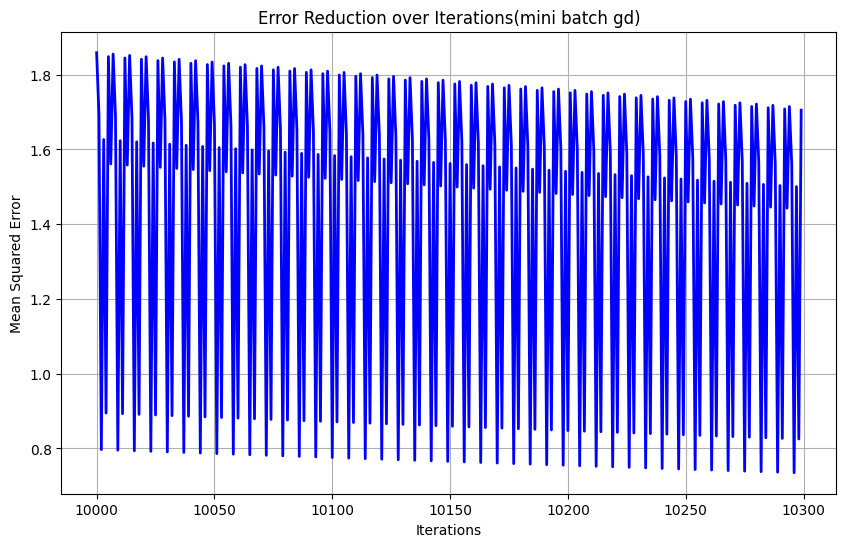

In [7]:
import matplotlib.pyplot as plt
def plot_loss(epochs,loss_history,title):
    plt.figure(figsize = (10,6))
    plt.plot(epochs,loss_history,color='blue',linewidth=2)
    plt.title(title)
    plt.xlabel("Iterations")
    plt.ylabel("Mean Squared Error")
    plt.grid(True)
    plt.show()

plot_loss(range(10000,10300),loss_history[10000:10300],"Error Reduction over Iterations(mini batch gd)")

# Stochastic GD 

In [8]:
epochs = 500
learning_rate =0.001
loss_history = []
n_samples = len(performance)
batch_size = 16
for epoch in range(epochs):
    for i in range(n_samples):
        single_performance = performance[i]
        single_years_of_exp = years_of_exp[i]
        single_projects_completed = projects_completed[i]
        single_bonus = bonus[i]
        
        pred_bonus = w1 * single_performance + w2 * single_years_of_exp + w3 * single_projects_completed + bias
        loss = (pred_bonus - single_bonus)**2
        if i % 10 == 0:
            loss_history.append(loss.item())
        loss.backward()
    
        with torch.no_grad():
            w1 -= learning_rate * w1.grad
            w2 -= learning_rate * w2.grad
            w3 -= learning_rate * w3.grad
            bias -= learning_rate * bias.grad
    
        w1.grad.zero_()
        w2.grad.zero_()
        w3.grad.zero_()
        bias.grad.zero_()
        
    if (epoch+1) % 100 == 0:
        print(f"Epoch[{epoch+1}/{epochs}], Loss : {loss.item():0.2f}")
print(f" Learned Weights : w1 = {w1.item()} , w2 = {w2.item()},w3 = {w3.item()} ")
print(f" Learned bias : {bias.item()}")

Epoch[100/500], Loss : 0.00
Epoch[200/500], Loss : 0.00
Epoch[300/500], Loss : 0.00
Epoch[400/500], Loss : 0.00
Epoch[500/500], Loss : 0.00
 Learned Weights : w1 = 12.00007152557373 , w2 = 6.000066757202148,w3 = 2.000014305114746 
 Learned bias : 19.998945236206055


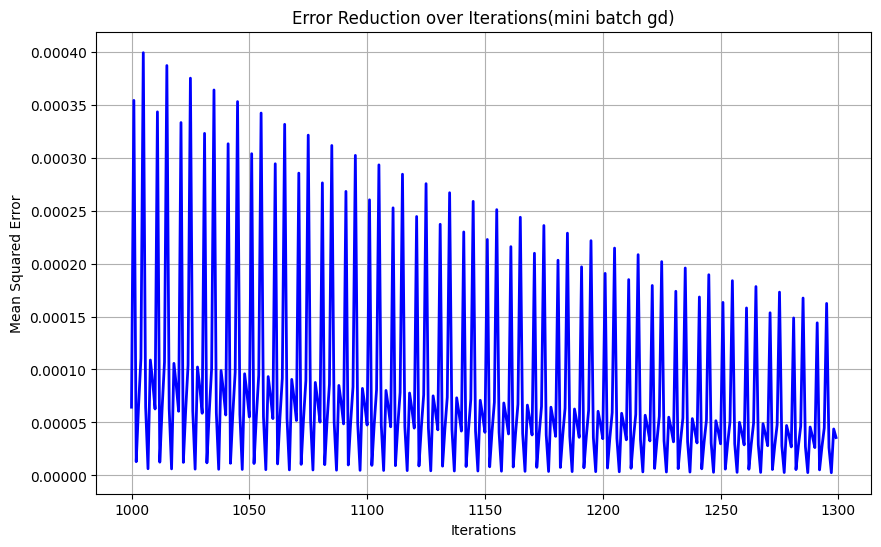

In [10]:
plot_loss(range(1000,1300),loss_history[1000:1300],"Error Reduction over Iterations(mini batch gd)")